# **🤖 Impact Study of AI on Digital Media**
This dataset explores the influence of AI-generated content across various industries, including journalism, social media, entertainment, and marketing. It provides insights into public sentiment, engagement trends, economic impact, and regulatory responses over time. With AI-generated content becoming increasingly prevalent, this dataset serves as a valuable resource for data analysts, business strategists, and machine learning researchers to study trends, detect biases, and predict future AI adoption patterns

### **Database Overview**
| Column Name | Data Type | Description | Key Values / Ranges |
| :--- | :--- | :--- | :--- |
| **`Country`** | `Categorical (String)` | The country where the AI content impact is recorded. | France, India, USA, China, South Korea, etc. |
| **`Year`** | `Numerical (Integer)` | The year of observation. | `2020` to `2025` |
| **`Industry`** | `Categorical (String)` | The industry/sector experiencing AI-generated content influence. | Media, Gaming, Legal, Automotive, Healthcare, etc. |
| **`AI Adoption Rate (%)`** | `Numerical (Float)` | Percentage of organizations adopting AI in the country/industry. | `10.5%` to `94.8%` |
| **`AI-Generated Content Volume (%)`** | `Numerical (Float)` | The percentage of AI-generated content used in that industry. | `1.04%` to `99.1%` |
| **`Job Loss Due to AI (%)`** | `Numerical (Float)` | Estimated percentage of job displacement attributed to AI. | `0.09%` to `49.7%` |
| **`Revenue Increase Due to AI (%)`** | `Numerical (Float)` | Percentage of revenue increase attributed directly to AI implementation. | `0.14%` to `79.5%` |
| **`Human-AI Collaboration Rate (%)`** | `Numerical (Float)` | The rate of active collaboration between humans and AI tools in workflow processes. | `20.2%` to `88.3%` |
| **`Top AI Tools Used`** | `Categorical (String)` | The primary AI technology/tool utilized within the sector. | ChatGPT, Midjourney, Claude, DALL-E, Stable Diffusion, etc. |
| **`Regulation Status`** | `Categorical (String)` | The level of regulatory enforcement regarding AI in that jurisdiction. | `Strict`, `Moderate`, `Lenient` |
| **`Consumer Trust in AI (%)`** | `Numerical (Float)` | The level of public/consumer confidence in AI-generated output. | `30.1%` to `89.9%` |
| **`Market Share of AI Companies (%)`** | `Numerical (Float)` | The market share control of leading AI companies in the region/sector. | `1.18%` to `49.3%` |

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
from matplotlib import pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/atharvasoundankar/impact-of-ai-on-digital-media-2020-2025/Global_AI_Content_Impact_Dataset.csv


In [2]:
data = pd.read_csv('/kaggle/input/datasets/atharvasoundankar/impact-of-ai-on-digital-media-2020-2025/Global_AI_Content_Impact_Dataset.csv')
data.shape

(200, 12)

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Country                                     200 non-null    object 
 1   Year                                        200 non-null    int64  
 2   Industry                                    200 non-null    object 
 3   AI Adoption Rate (%)                        200 non-null    float64
 4   AI-Generated Content Volume (TBs per year)  200 non-null    float64
 5   Job Loss Due to AI (%)                      200 non-null    float64
 6   Revenue Increase Due to AI (%)              200 non-null    float64
 7   Human-AI Collaboration Rate (%)             200 non-null    float64
 8   Top AI Tools Used                           200 non-null    object 
 9   Regulation Status                           200 non-null    object 
 10  Consumer Trust

In [4]:
data.isnull().sum()

Country                                       0
Year                                          0
Industry                                      0
AI Adoption Rate (%)                          0
AI-Generated Content Volume (TBs per year)    0
Job Loss Due to AI (%)                        0
Revenue Increase Due to AI (%)                0
Human-AI Collaboration Rate (%)               0
Top AI Tools Used                             0
Regulation Status                             0
Consumer Trust in AI (%)                      0
Market Share of AI Companies (%)              0
dtype: int64

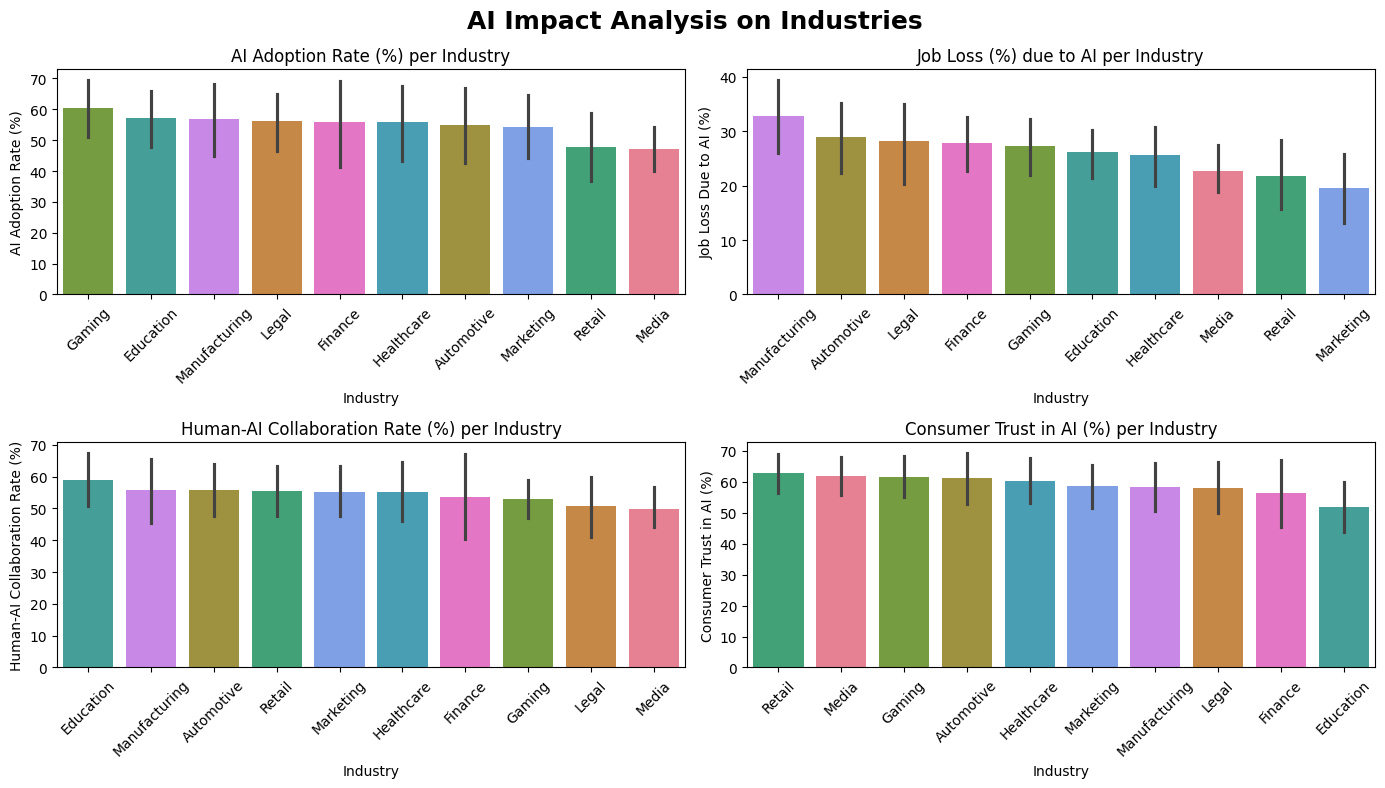

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
custom_palette = ["#1A365D", "#00B4D8", "#7209B7", "#B5179E", "#4CC9F0", "#FF4D6D"]
sns.set_palette(sns.color_palette(custom_palette))

fig.suptitle("AI Impact Analysis on Industries", fontsize=18, fontweight='bold', y=0.98)

order_adoption = data.groupby("Industry")["AI Adoption Rate (%)"].mean().sort_values(ascending=False).index
order_job_loss = data.groupby("Industry")["Job Loss Due to AI (%)"].mean().sort_values(ascending=False).index
order_collab   = data.groupby("Industry")["Human-AI Collaboration Rate (%)"].mean().sort_values(ascending=False).index
order_trust    = data.groupby("Industry")["Consumer Trust in AI (%)"].mean().sort_values(ascending=False).index

# 1. AI Adoption Rate (%) per Industry
sns.barplot(x="Industry", y="AI Adoption Rate (%)", data=data, hue="Industry", 
            order=order_adoption, ax=axes[0, 0], legend=False)
axes[0, 0].set_title("AI Adoption Rate (%) per Industry")
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Job Loss (%) due to AI per Industry
sns.barplot(x="Industry", y="Job Loss Due to AI (%)", data=data, hue="Industry", 
            order=order_job_loss, ax=axes[0, 1], legend=False)
axes[0, 1].set_title("Job Loss (%) due to AI per Industry")
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Human-AI Collaboration Rate (%) per Industry
sns.barplot(x="Industry", y="Human-AI Collaboration Rate (%)", data=data, hue="Industry", 
            order=order_collab, ax=axes[1, 0], legend=False)
axes[1, 0].set_title("Human-AI Collaboration Rate (%) per Industry")
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Consumer Trust in AI (%) per Industry
sns.barplot(x="Industry", y="Consumer Trust in AI (%)", data=data, hue="Industry", 
            order=order_trust, ax=axes[1, 1], legend=False)
axes[1, 1].set_title("Consumer Trust in AI (%) per Industry")
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

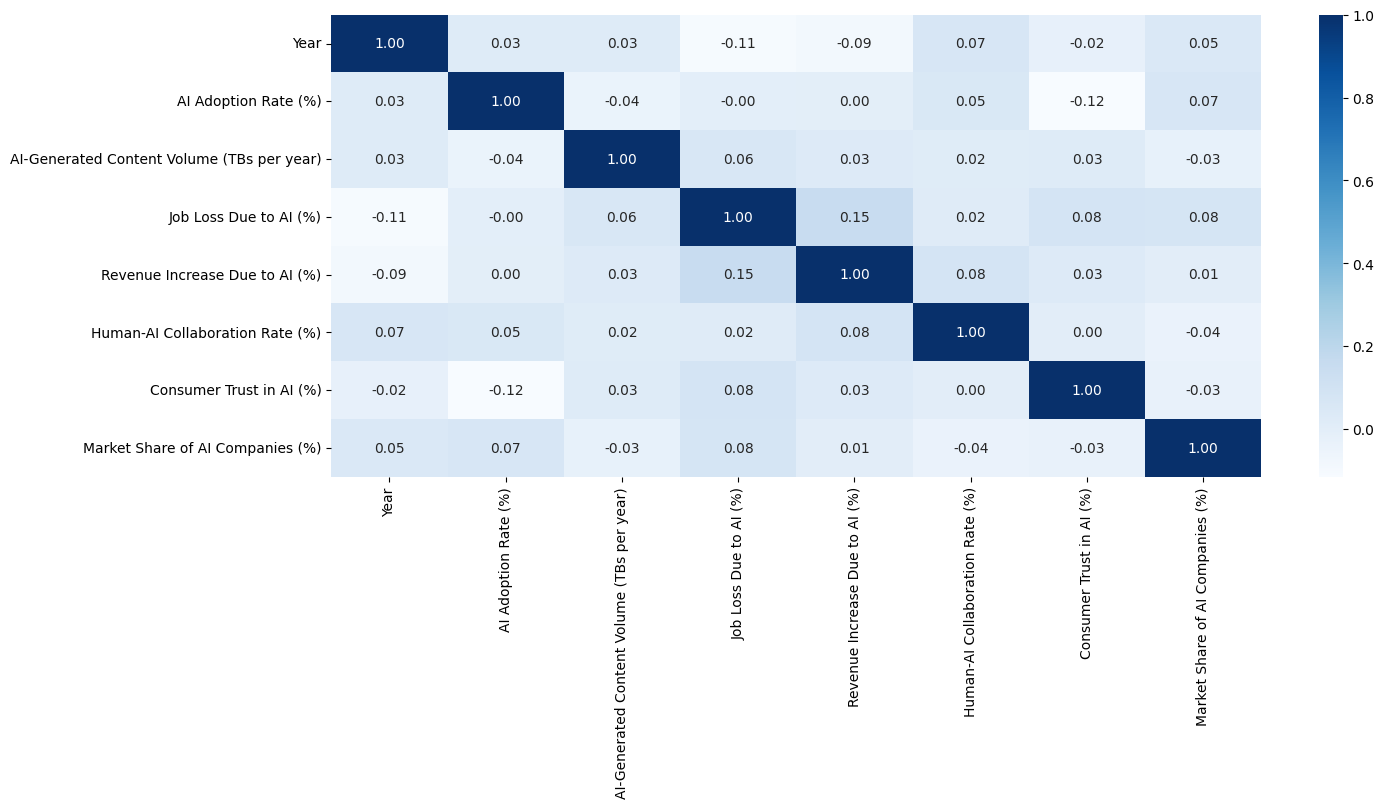

In [6]:
plt.figure(figsize=(15, 6))
corr_data = data.corr(numeric_only=True)
sns.heatmap(corr_data, cmap="Blues", fmt=".2f", annot=True)

plt.show()

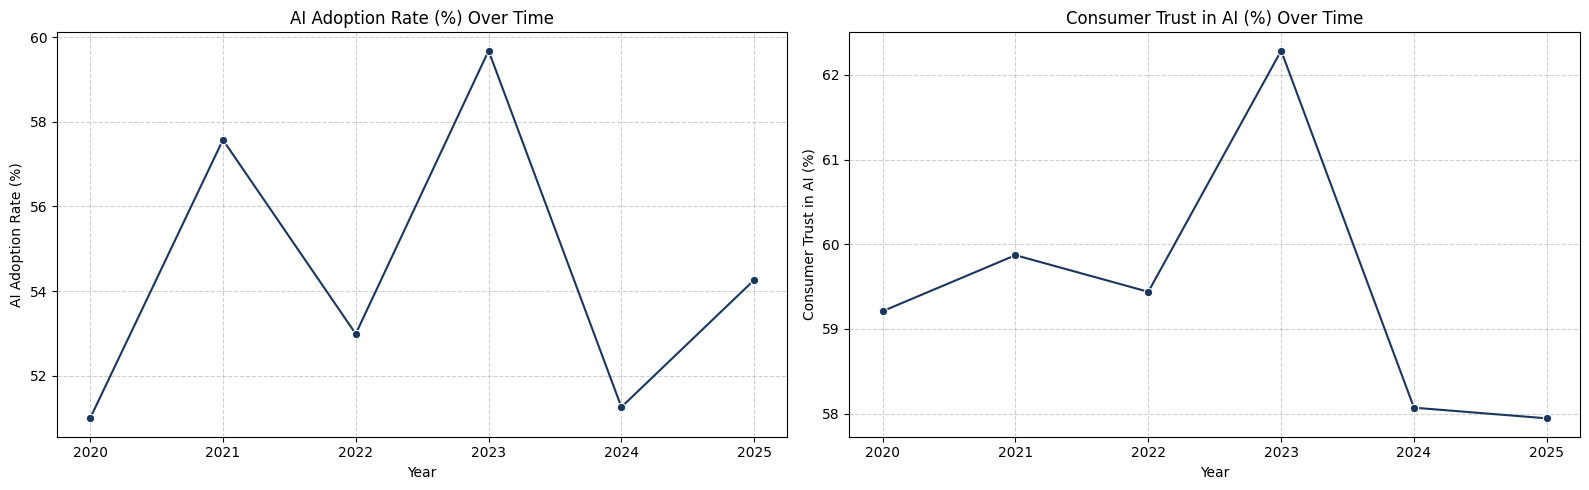

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. AI Adoption Rate over time
sns.lineplot(x="Year", y="AI Adoption Rate (%)", data=data, ax=axes[0], marker="o", errorbar=None)
axes[0].set_title("AI Adoption Rate (%) Over Time")
axes[0].grid(True, linestyle="--", alpha=0.6) # Adds a clean grid background

# 2. Consumer Trust over time
sns.lineplot(x="Year", y="Consumer Trust in AI (%)", data=data, ax=axes[1], marker="o", errorbar=None)
axes[1].set_title("Consumer Trust in AI (%) Over Time")
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()